# 파이프라인 V2: 공정 단위 Split → 베이스라인 선정 → 인코넬 학습 → 몰리브덴 파인튜닝

## 데이터 소스
- **원본 (NAS)**: `Z:\한경훈\인코넬 데이터\●공정&시간 반영 이미지\Dataset_extracted`
- **Split 저장 (NAS)**: `Z:\한경훈\몰리브덴 데이터\●공정&시점 반영 이미지\라벨링\split`

## 공정(test_name) 단위 Split 배정
| Split | 공정 수 | 공정 목록 |
|---|---|---|
| train (24개) | label0: 12개, label1: 12개 | Test1-5,7,8,10,12,28-30 + Test6,31-40,42 |
| val (9개) | label0: 7개, label1: 2개 | Val1-Val9 |
| test (6개) | label0: 3개, label1: 3개 | Test9,11,44 + Test41,43,45 |

> 같은 공정(test_name)의 이미지는 반드시 같은 split에만 포함 (데이터 누수 방지)
> label 2 제외, label 0(정상) / label 1(이상) 만 사용

## 파이프라인
| 단계 | 내용 |
|---|---|
| STEP 0 | 공정 단위 데이터 분할 (NAS → NAS, 원본 보존) |
| STEP 1 | 베이스라인 모델 선정 (ResNet50 / ResNet101 / DenseNet121 / EfficientNet-B0) |
| STEP 2 | 선정 아키텍처 × 3동결전략 → 모델 A 확정 |
| STEP 3 | 모델 A → 몰리브덴 파인튜닝 × 3동결전략 → 모델 B 선정 |
| STEP 4 | 인코넬 테스트셋 A vs B 최종 비교 (파국적 망각 검증) |

In [1]:
import os, time, copy, random, gc, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 한글 폰트
font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

디바이스: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 31.8 GB


c:\Users\msi\anaconda3\envs\ai_project\lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5090 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5090 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [2]:
import re

# ── NAS 경로 - 인코넬 ──────────────────────────────────────────
INCONEL_SRC = r'Z:\한경훈\인코넬 데이터\●공정&시간 반영 이미지\Dataset_extracted'
INCONEL_DIR = r'Z:\한경훈\인코넬 데이터\●공정&시간 반영 이미지\Dataset_extracted\split'

# ── NAS 경로 - 몰리브덴 ────────────────────────────────────────
MOLY_SRC    = r'Z:\한경훈\몰리브덴 데이터\●공정&시점 반영 이미지\라벨링'
MOLY_DIR    = r'Z:\한경훈\몰리브덴 데이터\●공정&시점 반영 이미지\라벨링\split'

SAVE_DIR    = r'C:\Users\msi\Desktop\팀프로젝트\인공지능\code\main\checkpoints_pipeline_v2'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 인코넬: 공정 prefix 기준 Split ───────────────────────────
# 파일명 예: Test1_160A_20TS_160WFR_t0.12s.png → prefix: Test1
INCONEL_TRAIN_PROCS = {
    'Test1', 'Test2', 'Test3', 'Test4', 'Test5', 'Test7', 'Test8',
    'Test10', 'Test12', 'Test28', 'Test29', 'Test30',             # label0 공정
    'Test6', 'Test31', 'Test32', 'Test33', 'Test34', 'Test35',
    'Test36', 'Test37', 'Test38', 'Test39', 'Test40', 'Test42',   # label1 공정
}
INCONEL_VAL_PROCS  = {'Val1', 'Val2', 'Val3', 'Val4', 'Val5', 'Val6', 'Val7', 'Val8', 'Val9'}
INCONEL_TEST_PROCS = {'Test9', 'Test11', 'Test44', 'Test41', 'Test43', 'Test45'}

# ── 몰리브덴: 공정 번호 기준 Split ───────────────────────────
# 파일명 예: 04._STO3_..._t17.92s.png → 번호: 4
# Val  : 38~50번 (Val 계열 공정)
# Test : 4, 35, 36, 37번 (이상 포함 STO + 인접 정상 STO)
# Train: 나머지 (STO 01~34 + BK 51~70)
MOLY_VAL_NUMS  = set(range(38, 51))
MOLY_TEST_NUMS = {4, 35, 36, 37}

# ── 공통 하이퍼파라미터 ───────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42
CLASS_NAMES = ['정상', '이상']

# ── Early Stopping ────────────────────────────────────────────
MAX_EPOCHS = 30
PATIENCE   = 7

# ── 베이스라인 비교 아키텍처 ──────────────────────────────────
BASELINE_ARCHS = ['resnet50', 'resnet101', 'densenet121', 'efficientnet_b0']
SELECTED_ARCH  = None

# ── 학습률 ────────────────────────────────────────────────────
IN_LR   = 1e-4
MOLY_LR = 1e-5

FREEZE_RATIOS = [0.0, 0.5, 0.85]
FREEZE_LABELS = ['전략1(0%동결)', '전략2(50%동결)', '전략3(85%동결)']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('설정 완료')
print(f'  인코넬 Train:{len(INCONEL_TRAIN_PROCS)}공정 / Val:{len(INCONEL_VAL_PROCS)}공정 / Test:{len(INCONEL_TEST_PROCS)}공정')
print(f'  몰리브덴 Val:38~50번 / Test:{{4,35,36,37}}번 / Train:나머지')

설정 완료
  인코넬 Train:24공정 / Val:9공정 / Test:6공정
  몰리브덴 Val:38~50번 / Test:{4,35,36,37}번 / Train:나머지


## STEP 0. 데이터 분할 (영상 단위, 최초 1회만 실행)

### NAS에 있는 원본 데이터 split

In [3]:
# ── STEP 0-A: 인코넬 공정 단위 Split (실제 파일 기준, 원본 보존) ─
inconel_split_dirs = [os.path.join(INCONEL_DIR, s, c)
                      for s in ['train', 'val', 'test'] for c in ['0', '1']]

if all(os.path.exists(d) and len(os.listdir(d)) > 0 for d in inconel_split_dirs):
    total = sum(len(os.listdir(d)) for d in inconel_split_dirs)
    print(f'[인코넬] 분할 폴더 이미 존재 ({total}개) → 스킵')
else:
    print('[인코넬] 공정 단위 분할 시작...')
    for d in inconel_split_dirs:
        os.makedirs(d, exist_ok=True)

    def get_inconel_split(fname):
        process = re.sub(r'_t[\d.]+s\.png$', '', fname)
        prefix = process.split('_')[0]
        if prefix in INCONEL_TRAIN_PROCS: return 'train'
        if prefix in INCONEL_VAL_PROCS:   return 'val'
        if prefix in INCONEL_TEST_PROCS:  return 'test'
        return None

    stats = {'train': {0:0, 1:0}, 'val': {0:0, 1:0}, 'test': {0:0, 1:0}}
    skipped = 0
    for cls in ['0', '1']:
        for fname in os.listdir(os.path.join(INCONEL_SRC, cls)):
            split = get_inconel_split(fname)
            if split is None:
                skipped += 1
                continue
            shutil.copy2(os.path.join(INCONEL_SRC, cls, fname),
                         os.path.join(INCONEL_DIR, split, cls, fname))
            stats[split][int(cls)] += 1

    print(f'\n{"Split":<8} {"정상(0)":>10} {"이상(1)":>10} {"합계":>8}')
    print('-' * 40)
    for sp in ['train', 'val', 'test']:
        s = stats[sp]
        print(f'{sp:<8} {s[0]:>10} {s[1]:>10} {s[0]+s[1]:>8}')
    if skipped: print(f'미배정: {skipped}개')
    print('[인코넬] 분할 완료!')

[인코넬] 분할 폴더 이미 존재 (10974개) → 스킵


In [4]:
# ── STEP 0-B: 몰리브덴 공정 단위 Split (실제 파일 기준, 원본 보존) ─
moly_split_dirs = [os.path.join(MOLY_DIR, s, c)
                   for s in ['train', 'val', 'test'] for c in ['0', '1']]

if all(os.path.exists(d) and len(os.listdir(d)) > 0 for d in moly_split_dirs):
    total = sum(len(os.listdir(d)) for d in moly_split_dirs)
    print(f'[몰리브덴] 분할 폴더 이미 존재 ({total}개) → 스킵')
else:
    print('[몰리브덴] 공정 단위 분할 시작...')
    for d in moly_split_dirs:
        os.makedirs(d, exist_ok=True)

    def get_moly_split(fname):
        process = re.sub(r'_t[\d.]+s\.png$', '', fname)
        num = int(process.split('.')[0])
        if num in MOLY_VAL_NUMS:  return 'val'
        if num in MOLY_TEST_NUMS: return 'test'
        return 'train'

    stats = {'train': {0:0, 1:0}, 'val': {0:0, 1:0}, 'test': {0:0, 1:0}}
    for cls in ['0', '1']:
        for fname in os.listdir(os.path.join(MOLY_SRC, cls)):
            split = get_moly_split(fname)
            shutil.copy2(os.path.join(MOLY_SRC, cls, fname),
                         os.path.join(MOLY_DIR, split, cls, fname))
            stats[split][int(cls)] += 1

    print(f'\n{"Split":<8} {"정상(0)":>10} {"이상(1)":>10} {"합계":>8}')
    print('-' * 40)
    for sp in ['train', 'val', 'test']:
        s = stats[sp]
        print(f'{sp:<8} {s[0]:>10} {s[1]:>10} {s[0]+s[1]:>8}')
    print('[몰리브덴] 분할 완료!')

[몰리브덴] 분할 폴더 이미 존재 (22989개) → 스킵


## 유틸리티 함수

In [5]:
import torch.nn.functional as F

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

use_amp = device.type == 'cuda'
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)


# ── Focal Loss (몰리브덴 극단적 불균형 대응) ─────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha.to(device)  # 클래스별 가중치 텐서
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# ── 인코넬 DataLoader (1.02:1 균형 → 일반 shuffle) ──────────
def get_inconel_loaders():
    tr_ds = datasets.ImageFolder(os.path.join(INCONEL_DIR, 'train'), transform=transform)
    va_ds = datasets.ImageFolder(os.path.join(INCONEL_DIR, 'val'),   transform=transform)
    te_ds = datasets.ImageFolder(os.path.join(INCONEL_DIR, 'test'),  transform=transform)
    counts = np.bincount(tr_ds.targets)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True, persistent_workers=True)
    print(f'인코넬 train:{len(tr_ds)}장  val:{len(va_ds)}장  test:{len(te_ds)}장')
    print(f'  클래스 분포 → 0:{counts[0]}  1:{counts[1]}  (비율 {counts[0]/counts[1]:.2f}:1)')
    return tr_loader, va_loader, te_loader


# ── 몰리브덴 DataLoader (108:1 불균형 → WRS + Focal alpha) ──
def get_moly_loaders():
    tr_ds = datasets.ImageFolder(os.path.join(MOLY_DIR, 'train'), transform=transform)
    va_ds = datasets.ImageFolder(os.path.join(MOLY_DIR, 'val'),   transform=transform)
    te_ds = datasets.ImageFolder(os.path.join(MOLY_DIR, 'test'),  transform=transform)

    labels = tr_ds.targets
    counts = np.bincount(labels)
    n0, n1 = int(counts[0]), int(counts[1])

    # WeightedRandomSampler: 배치 내 클래스 균형
    s_w     = [1.0 / counts[l] for l in labels]
    sampler = WeightedRandomSampler(s_w, len(s_w), replacement=True)

    # Focal Loss alpha: Class-Balanced (β=0.9999) 기반 가중치
    beta    = 0.9999
    eff_n0  = (1 - beta ** n0) / (1 - beta)
    eff_n1  = (1 - beta ** n1) / (1 - beta)
    alpha   = torch.tensor([1.0 / eff_n0, 1.0 / eff_n1], dtype=torch.float32)
    alpha   = alpha / alpha.sum()  # 정규화

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=4, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True, persistent_workers=True)
    print(f'몰리브덴 train:{len(tr_ds)}장  val:{len(va_ds)}장  test:{len(te_ds)}장')
    print(f'  클래스 분포 → 0:{n0}  1:{n1}  (비율 {n0/n1:.0f}:1)')
    print(f'  Focal alpha → 0:{alpha[0]:.4f}  1:{alpha[1]:.4f}  γ=2.0')
    return tr_loader, va_loader, te_loader, alpha


def build_model_by_arch(arch, num_classes=2):
    if arch == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif arch == 'resnet101':
        m = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif arch == 'densenet121':
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif arch == 'efficientnet_b0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f'지원하지 않는 아키텍처: {arch}')
    total = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'    {arch}: 총 파라미터 {total:.1f}M')
    return m.to(device)


def apply_freeze(model, freeze_ratio):
    all_params = list(model.parameters())
    n_freeze   = int(len(all_params) * freeze_ratio)
    for i, p in enumerate(all_params):
        p.requires_grad = (i >= n_freeze)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'    학습 파라미터: {trainable/1e6:.2f}M / {total/1e6:.2f}M ({100*trainable/total:.1f}%)')


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                out  = model(imgs)
                loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def get_predictions(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                out = model(imgs)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(labels_all), np.array(preds_all)


def run_training(model, tr_loader, va_loader, criterion,
                 optimizer, scheduler, save_path,
                 max_epochs=MAX_EPOCHS, patience=PATIENCE):
    best_val_loss = float('inf')
    best_w        = None
    no_improve    = 0
    history       = {'tr_loss': [], 'tr_acc': [], 'va_loss': [], 'va_acc': []}

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, va_loader, criterion)
        scheduler.step()

        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['va_loss'].append(va_loss)
        history['va_acc'].append(va_acc)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_w        = copy.deepcopy(model.state_dict())
            torch.save(best_w, save_path)
            no_improve = 0
            flag = '★'
        else:
            no_improve += 1
            flag = f'({no_improve}/{patience})'

        print(f'    Epoch {epoch:02d}/{max_epochs} | Train {tr_acc:.4f} | Val {va_acc:.4f} '
              f'| {flag} | {time.time()-t0:.1f}s')

        if no_improve >= patience:
            print(f'    → Early stopping (epoch {epoch})')
            break

    model.load_state_dict(best_w)
    best_val_acc = max(history['va_acc'])
    print(f'    완료: {epoch} 에폭 | Best Val Acc: {best_val_acc:.4f}')
    return model, history, best_val_acc


print(f'유틸리티 함수 정의 완료  |  AMP={use_amp}  |  BATCH={BATCH_SIZE}')

유틸리티 함수 정의 완료  |  AMP=True  |  BATCH=32


## STEP 1. 베이스라인 모델 선정

논문 11 방식 적용: 여러 CNN 아키텍처를 인코넬 데이터로 동일 조건 학습 후 최적 아키텍처 선정

| 아키텍처 | 파라미터 수 | 특징 |
|---|---|---|
| ResNet50 | 25.6M | 잔차 연결, 산업 표준 |
| ResNet101 | 44.5M | 더 깊은 ResNet |
| DenseNet121 | 8.0M | 논문 11 선정 아키텍처 (DenseNet169 경량버전) |
| EfficientNet-B0 | 5.3M | 경량 고효율 |

- **학습 조건**: Max Epochs=15, Early Stopping(patience=5), LR=1e-4, 전체 파인튜닝 (동결 없음)
- **선정 기준**: Inconel Val Macro F1 최고 모델
- **선정된 아키텍처** → STEP 2 동결 전략 실험의 백본으로 사용

In [6]:
inconel_tr, inconel_va, inconel_te = get_inconel_loaders()

step1_baseline = {}

for arch in BASELINE_ARCHS:
    print(f'\n{"="*65}')
    print(f'  [STEP 1] 베이스라인 비교  |  {arch}')
    print(f'{"="*65}')

    gc.collect()
    torch.cuda.empty_cache()

    model = build_model_by_arch(arch)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=IN_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    save_path = os.path.join(SAVE_DIR, f'baseline_{arch}.pth')

    model, history, best_va = run_training(
        model, inconel_tr, inconel_va,
        criterion, optimizer, scheduler, save_path
    )

    y_va_true, y_va_pred = get_predictions(model, inconel_va)
    val_f1 = float(f1_score(y_va_true, y_va_pred, average='macro'))

    y_te_true, y_te_pred = get_predictions(model, inconel_te)
    test_acc = float((y_te_true == y_te_pred).mean())
    test_f1  = float(f1_score(y_te_true, y_te_pred, average='macro'))

    step1_baseline[arch] = {
        'history'  : history,
        'val_f1'   : val_f1,
        'test_acc' : test_acc,
        'test_f1'  : test_f1,
        'save_path': save_path,
    }
    print(f'  → Val F1: {val_f1:.4f}  |  Test Acc: {test_acc:.4f}  |  Test F1: {test_f1:.4f}')

    model.cpu()
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

print('\nSTEP 1 베이스라인 비교 완료!')

인코넬 train:6510장  val:2804장  test:1660장
  클래스 분포 → 0:3322  1:3188  (비율 1.04:1)

  [STEP 1] 베이스라인 비교  |  resnet50
    resnet50: 총 파라미터 23.5M
    Epoch 01/30 | Train 0.9916 | Val 0.7525 | ★ | 149.8s
    Epoch 02/30 | Train 1.0000 | Val 0.7553 | (1/7) | 134.5s
    Epoch 03/30 | Train 1.0000 | Val 0.7557 | (2/7) | 131.2s
    Epoch 04/30 | Train 1.0000 | Val 0.7553 | (3/7) | 136.1s
    Epoch 05/30 | Train 0.9991 | Val 0.6641 | (4/7) | 132.5s
    Epoch 06/30 | Train 0.9991 | Val 0.5656 | (5/7) | 131.4s
    Epoch 07/30 | Train 1.0000 | Val 0.6412 | (6/7) | 130.9s
    Epoch 08/30 | Train 1.0000 | Val 0.6209 | (7/7) | 137.2s
    → Early stopping (epoch 8)
    완료: 8 에폭 | Best Val Acc: 0.7557
  → Val F1: 0.7185  |  Test Acc: 0.8048  |  Test F1: 0.7893

  [STEP 1] 베이스라인 비교  |  resnet101
    resnet101: 총 파라미터 42.5M
    Epoch 01/30 | Train 0.9902 | Val 0.7400 | ★ | 132.7s
    Epoch 02/30 | Train 1.0000 | Val 0.7486 | (1/7) | 129.9s
    Epoch 03/30 | Train 1.0000 | Val 0.7486 | (2/7) | 132.5s
    Epoc

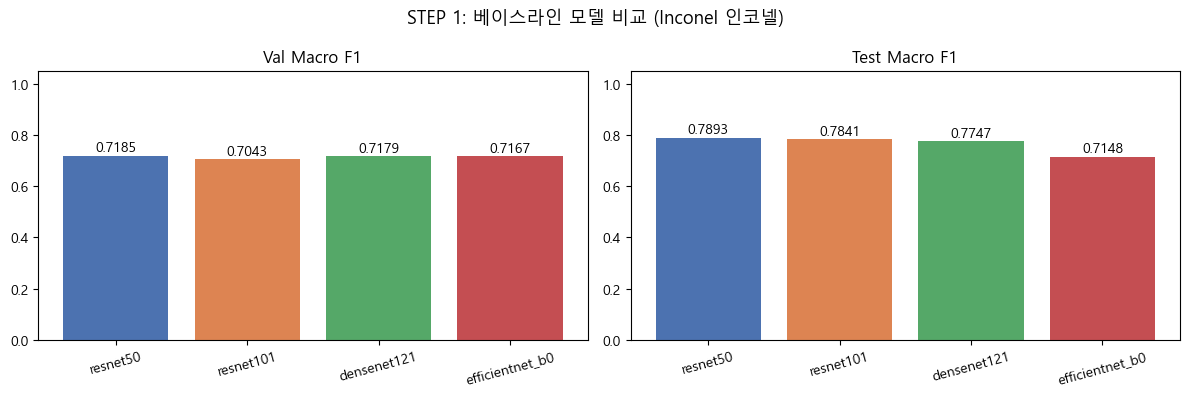


아키텍처                    Val F1   Test Acc   Test F1
----------------------------------------------------
resnet50                0.7185     0.8048    0.7893
resnet101               0.7043     0.8024    0.7841
densenet121             0.7179     0.7904    0.7747
efficientnet_b0         0.7167     0.7446    0.7148

  베이스라인 선정: resnet50
  Val F1  : 0.7185
  Test F1 : 0.7893
  → STEP 2에서 이 아키텍처로 동결 전략 실험 진행


In [7]:
# ── STEP 1 결과 시각화 & 베이스라인 아키텍처 선정 ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('STEP 1: 베이스라인 모델 비교 (Inconel 인코넬)', fontsize=13)

arch_labels = list(step1_baseline.keys())
val_f1s  = [step1_baseline[a]['val_f1']  for a in arch_labels]
test_f1s = [step1_baseline[a]['test_f1'] for a in arch_labels]
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, vals, title in zip(axes, [val_f1s, test_f1s], ['Val Macro F1', 'Test Macro F1']):
    bars = ax.bar(arch_labels, vals, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step1_baseline_comparison.png'), dpi=150)
plt.show()

print(f'\n{"아키텍처":<20} {"Val F1":>9} {"Test Acc":>10} {"Test F1":>9}')
print('-' * 52)
for arch in arch_labels:
    r = step1_baseline[arch]
    print(f'{arch:<20} {r["val_f1"]:>9.4f} {r["test_acc"]:>10.4f} {r["test_f1"]:>9.4f}')

SELECTED_ARCH = max(step1_baseline, key=lambda k: step1_baseline[k]['val_f1'])

print(f'\n{"="*50}')
print(f'  베이스라인 선정: {SELECTED_ARCH}')
print(f'  Val F1  : {step1_baseline[SELECTED_ARCH]["val_f1"]:.4f}')
print(f'  Test F1 : {step1_baseline[SELECTED_ARCH]["test_f1"]:.4f}')
print(f'  → STEP 2에서 이 아키텍처로 동결 전략 실험 진행')
print(f'{"="*50}')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# ── 폰트 설정 ─────────────────────────────────────────────────
font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 ────────────────────────────────────────────────────
arch_labels = list(step1_baseline.keys())
test_acc = [step1_baseline[a]['test_acc'] for a in arch_labels]
test_f1  = [step1_baseline[a]['test_f1']  for a in arch_labels]
val_f1   = [step1_baseline[a]['val_f1']   for a in arch_labels]

x = np.arange(len(arch_labels))
w = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

# ── 시각화 ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

b1 = ax.bar(x - w, test_acc, w, label='Test Accuracy', color=colors[0], zorder=3)
b2 = ax.bar(x,     test_f1,  w, label='Test Macro F1', color=colors[1], zorder=3)
b3 = ax.bar(x + w, val_f1,   w, label='Val Macro F1',  color=colors[2], zorder=3)

# 수치 레이블
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                f'{h:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(arch_labels, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('STEP 1: 아키텍처별 성능 비교 (Accuracy & F1-score)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)

# 선정 아키텍처 강조
best_idx = arch_labels.index(SELECTED_ARCH)
ax.axvspan(best_idx - 0.45, best_idx + 0.45, color='gold', alpha=0.15, zorder=0)
ax.text(best_idx, 1.08, '★ 선정', ha='center', fontsize=11, color='goldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step1_accuracy_f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 테이블 출력 ──────────────────────────────────────────
print(f'\n{"아키텍처":<20} {"Test Accuracy":>14} {"Test Macro F1":>14} {"Val Macro F1":>13}')
print('─' * 63)
for arch in arch_labels:
    r = step1_baseline[arch]
    marker = '  ← 선정' if arch == SELECTED_ARCH else ''
    print(f'{arch:<20} {r["test_acc"]:>14.4f} {r["test_f1"]:>14.4f} {r["val_f1"]:>13.4f}{marker}')


## STEP 2. 인코넬 학습: 선정 아키텍처 × 3동결전략 → 모델 A 확정

- STEP 1에서 선정된 아키텍처(`SELECTED_ARCH`) 사용
- LR: 1e-4, Max Epochs=15, Early Stopping(patience=5)
- WeightedRandomSampler (클래스 불균형 처리)
- Val loss 기준 best 저장, Test Macro F1 기준 모델 A 선정

In [8]:
step2 = {}

for freeze_ratio, freeze_label in zip(FREEZE_RATIOS, FREEZE_LABELS):
    print(f'\n{"="*65}')
    print(f'  [STEP 2] 인코넬 학습  |  {SELECTED_ARCH}  |  {freeze_label}')
    print(f'{"="*65}')

    gc.collect()
    torch.cuda.empty_cache()

    model = build_model_by_arch(SELECTED_ARCH)
    apply_freeze(model, freeze_ratio)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=IN_LR, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    save_path = os.path.join(SAVE_DIR, f'IN_{SELECTED_ARCH}_fr{int(freeze_ratio*100)}.pth')

    model, history, best_va = run_training(
        model, inconel_tr, inconel_va,
        criterion, optimizer, scheduler, save_path
    )

    y_true, y_pred = get_predictions(model, inconel_te)
    in_acc = float((y_true == y_pred).mean())
    in_f1  = float(f1_score(y_true, y_pred, average='macro'))

    step2[freeze_label] = {
        'history'    : history,
        'best_va_acc': best_va,
        'in_acc'     : in_acc,
        'in_f1'      : in_f1,
        'save_path'  : save_path,
    }
    print(f'  → Inconel Test Acc: {in_acc:.4f}  |  Macro F1: {in_f1:.4f}')

    model.cpu()
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

print('\nSTEP 2 완료!')


  [STEP 2] 인코넬 학습  |  resnet50  |  전략1(0%동결)
    resnet50: 총 파라미터 23.5M
    학습 파라미터: 23.51M / 23.51M (100.0%)
    Epoch 01/30 | Train 0.9928 | Val 0.7397 | ★ | 135.2s
    Epoch 02/30 | Train 1.0000 | Val 0.7521 | (1/7) | 135.4s
    Epoch 03/30 | Train 1.0000 | Val 0.7457 | (2/7) | 133.3s
    Epoch 04/30 | Train 1.0000 | Val 0.7532 | (3/7) | 142.8s
    Epoch 05/30 | Train 1.0000 | Val 0.7464 | (4/7) | 133.9s
    Epoch 06/30 | Train 1.0000 | Val 0.7439 | (5/7) | 133.9s
    Epoch 07/30 | Train 1.0000 | Val 0.7397 | (6/7) | 134.7s
    Epoch 08/30 | Train 1.0000 | Val 0.7496 | (7/7) | 135.7s
    → Early stopping (epoch 8)
    완료: 8 에폭 | Best Val Acc: 0.7532
  → Inconel Test Acc: 0.8096  |  Macro F1: 0.7930

  [STEP 2] 인코넬 학습  |  resnet50  |  전략2(50%동결)
    resnet50: 총 파라미터 23.5M
    학습 파라미터: 21.08M / 23.51M (89.7%)
    Epoch 01/30 | Train 0.9900 | Val 0.6280 | ★ | 138.8s
    Epoch 02/30 | Train 1.0000 | Val 0.6751 | (1/7) | 138.2s
    Epoch 03/30 | Train 1.0000 | Val 0.7297 | ★ | 138.0s
  

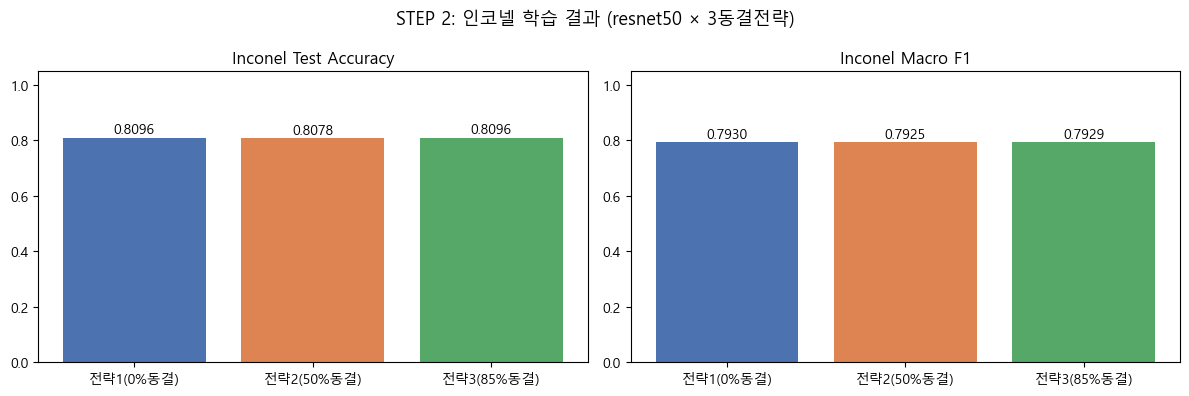


전략                       Val Acc   Test Acc       F1
----------------------------------------------------
전략1(0%동결)                 0.7532     0.8096   0.7930
전략2(50%동결)                0.7329     0.8078   0.7925
전략3(85%동결)                0.7514     0.8096   0.7929

  모델 A 선정: 전략1(0%동결)  (resnet50)
  Inconel Test Acc: 0.8096
  Inconel F1      : 0.7930


In [9]:
# ── STEP 2 결과 시각화 & 모델 A 선정 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'STEP 2: 인코넬 학습 결과 ({SELECTED_ARCH} × 3동결전략)', fontsize=13)

for ax, metric, title in zip(axes,
                              ['in_acc', 'in_f1'],
                              ['Inconel Test Accuracy', 'Inconel Macro F1']):
    vals = [step2[fl][metric] for fl in FREEZE_LABELS]
    bars = ax.bar(FREEZE_LABELS, vals, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step2_inconel_results.png'), dpi=150)
plt.show()

print(f'\n{"전략":<22} {"Val Acc":>9} {"Test Acc":>10} {"F1":>8}')
print('-' * 52)
for fl in FREEZE_LABELS:
    r = step2[fl]
    print(f'{fl:<22} {r["best_va_acc"]:>9.4f} {r["in_acc"]:>10.4f} {r["in_f1"]:>8.4f}')

best_fl_a    = max(step2, key=lambda k: step2[k]['in_f1'])
MODEL_A_PATH = step2[best_fl_a]['save_path']

print(f'\n{"="*50}')
print(f'  모델 A 선정: {best_fl_a}  ({SELECTED_ARCH})')
print(f'  Inconel Test Acc: {step2[best_fl_a]["in_acc"]:.4f}')
print(f'  Inconel F1      : {step2[best_fl_a]["in_f1"]:.4f}')
print(f'{"="*50}')

## STEP 3. 모델 B: ImageNet → 몰리브덴 → 인코넬 파인튜닝 (3동결전략)

- **Phase 1**: ImageNet 사전학습 모델을 몰리브덴 데이터로 학습 (전체 파인튜닝, LR=1e-4)
- **Phase 2**: 몰리브덴 학습 완료 모델 → 인코넬 파인튜닝 (3동결전략 × LR=1e-5)
- **선정 기준**: 인코넬 Test Macro F1 최고 전략 → **모델 B**
- **비교 목적**: 몰리브덴 중간 도메인 학습이 인코넬 탐지 성능에 미치는 영향 검증

In [ ]:
moly_tr, moly_va, moly_te, moly_focal_alpha = get_moly_loaders()

step3 = {}

for freeze_ratio, freeze_label in zip(FREEZE_RATIOS, FREEZE_LABELS):
    print(f'\n{"="*65}')
    print(f'  [STEP 3] 모델 B  |  {SELECTED_ARCH}  |  {freeze_label}')
    print(f'  경로: ImageNet → 몰리브덴(FocalLoss+WRS) → 인코넬')
    print(f'{"="*65}')

    gc.collect()
    torch.cuda.empty_cache()

    # ── Phase 1: ImageNet → 몰리브덴 (Focal Loss + WeightedRandomSampler) ──
    print(f'\n  [Phase 1] ImageNet → 몰리브덴  (FocalLoss γ=2, WRS, LR={IN_LR})')
    model = build_model_by_arch(SELECTED_ARCH)

    criterion  = FocalLoss(alpha=moly_focal_alpha)
    optimizer  = optim.AdamW(model.parameters(), lr=IN_LR, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    moly_save  = os.path.join(SAVE_DIR, f'B_moly_{SELECTED_ARCH}_fr{int(freeze_ratio*100)}.pth')

    model, moly_history, _ = run_training(
        model, moly_tr, moly_va,
        criterion, optimizer, scheduler, moly_save
    )

    y_m_true, y_m_pred = get_predictions(model, moly_te)
    moly_f1 = float(f1_score(y_m_true, y_m_pred, average='macro'))
    print(f'  → 몰리브덴 Test F1: {moly_f1:.4f}')

    del optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    # ── Phase 2: 몰리브덴 모델 → 인코넬 파인튜닝 (CrossEntropyLoss) ──────
    print(f'\n  [Phase 2] 몰리브덴 → 인코넬 ({freeze_label}, LR={MOLY_LR})')
    apply_freeze(model, freeze_ratio)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=MOLY_LR, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    in_save   = os.path.join(SAVE_DIR, f'B_in_{SELECTED_ARCH}_fr{int(freeze_ratio*100)}.pth')

    model, in_history, best_va = run_training(
        model, inconel_tr, inconel_va,
        criterion, optimizer, scheduler, in_save
    )

    y_true, y_pred = get_predictions(model, inconel_te)
    in_acc = float((y_true == y_pred).mean())
    in_f1  = float(f1_score(y_true, y_pred, average='macro'))

    step3[freeze_label] = {
        'moly_history': moly_history,
        'in_history'  : in_history,
        'best_va_acc' : best_va,
        'moly_f1'     : moly_f1,
        'in_acc'      : in_acc,
        'in_f1'       : in_f1,
        'save_path'   : in_save,
    }
    print(f'  → 인코넬 Test Acc: {in_acc:.4f}  |  Macro F1: {in_f1:.4f}')

    model.cpu()
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

print('\nSTEP 3 완료!')

몰리브덴 train:17214장  val:5089장  test:686장
  클래스 분포 → 0:17133  1:81  (비율 212:1)
  Focal alpha → 0:0.0097  1:0.9903  γ=2.0

  [STEP 3] 모델 B  |  resnet50  |  전략1(0%동결)
  경로: ImageNet → 몰리브덴(FocalLoss+WRS) → 인코넬

  [Phase 1] ImageNet → 몰리브덴  (FocalLoss γ=2, WRS, LR=0.0001)
    resnet50: 총 파라미터 23.5M
    Epoch 01/30 | Train 0.5099 | Val 0.0195 | ★ | 273.2s
    Epoch 02/30 | Train 0.5056 | Val 0.0450 | (1/7) | 259.3s
    Epoch 03/30 | Train 0.5351 | Val 0.2612 | (2/7) | 266.5s
    Epoch 04/30 | Train 0.5822 | Val 0.4268 | (3/7) | 258.7s
    Epoch 05/30 | Train 0.6546 | Val 0.6394 | (4/7) | 259.5s
    Epoch 06/30 | Train 0.7372 | Val 0.7084 | (5/7) | 262.3s
    Epoch 07/30 | Train 0.7952 | Val 0.7697 | (6/7) | 258.0s
    Epoch 08/30 | Train 0.8544 | Val 0.7950 | (7/7) | 264.2s
    → Early stopping (epoch 8)
    완료: 8 에폭 | Best Val Acc: 0.7950
  → 몰리브덴 Test F1: 0.1132

  [Phase 2] 몰리브덴 → 인코넬 (전략1(0%동결), LR=1e-05)
    학습 파라미터: 23.51M / 23.51M (100.0%)
    Epoch 01/30 | Train 0.8613 | Val 0.6833 |

In [ ]:
# ── STEP 3 결과 & 모델 B 선정 ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'STEP 3: 모델 B 인코넬 성능 (ImageNet→몰리→인코넬, {SELECTED_ARCH} × 3동결전략)', fontsize=13)

for ax, metric, title in zip(axes,
                              ['in_acc', 'in_f1'],
                              ['Inconel Test Accuracy', 'Inconel Macro F1']):
    vals = [step3[fl][metric] for fl in FREEZE_LABELS]
    bars = ax.bar(FREEZE_LABELS, vals, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step3_modelB_results.png'), dpi=150)
plt.show()

print(f'\n{"전략":<22} {"Moly F1":>9} {"Inconel Acc":>12} {"Inconel F1":>12}')
print('-' * 58)
for fl in FREEZE_LABELS:
    r = step3[fl]
    print(f'{fl:<22} {r["moly_f1"]:>9.4f} {r["in_acc"]:>12.4f} {r["in_f1"]:>12.4f}')

# 인코넬 F1 기준으로 모델 B 선정
best_fl_b    = max(step3, key=lambda k: step3[k]['in_f1'])
MODEL_B_PATH = step3[best_fl_b]['save_path']

print(f'\n{"="*50}')
print(f'  모델 B 선정: {best_fl_b}  ({SELECTED_ARCH})')
print(f'  경로: ImageNet → 몰리브덴 → 인코넬')
print(f'  Moly F1     : {step3[best_fl_b]["moly_f1"]:.4f}')
print(f'  Inconel Acc : {step3[best_fl_b]["in_acc"]:.4f}')
print(f'  Inconel F1  : {step3[best_fl_b]["in_f1"]:.4f}')
print(f'{"="*50}')

## STEP 4. 최종 비교: 모델 A vs 모델 B (인코넬 테스트셋)

| 모델 | 학습 경로 |
|---|---|
| **모델 A** | ImageNet → 인코넬 (STEP 2 선정) |
| **모델 B** | ImageNet → 몰리브덴 → 인코넬 (STEP 3 선정) |

**핵심 질문**: 몰리브덴 중간 도메인 학습이 인코넬 탐지 성능 향상에 도움이 되는가?

In [ ]:
gc.collect()
torch.cuda.empty_cache()

model_a = build_model_by_arch(SELECTED_ARCH)
model_a.load_state_dict(torch.load(MODEL_A_PATH, map_location=device))

model_b = build_model_by_arch(SELECTED_ARCH)
model_b.load_state_dict(torch.load(MODEL_B_PATH, map_location=device))

ya_true, ya_pred = get_predictions(model_a, inconel_te)
yb_true, yb_pred = get_predictions(model_b, inconel_te)

acc_a = float((ya_true == ya_pred).mean())
acc_b = float((yb_true == yb_pred).mean())
f1_a  = float(f1_score(ya_true, ya_pred, average='macro'))
f1_b  = float(f1_score(yb_true, yb_pred, average='macro'))

print('인코넬 테스트셋 최종 비교')
print(f'{"":30} {"Accuracy":>10} {"Macro F1":>10}')
print('-' * 52)
print(f'{"모델 A (인코넬만)":<30} {acc_a:>10.4f} {f1_a:>10.4f}')
print(f'{"모델 B (인코넬→몰리)":<30} {acc_b:>10.4f} {f1_b:>10.4f}')
print('-' * 52)
print(f'{"차이(B-A)":<30} {acc_b-acc_a:>+10.4f} {f1_b-f1_a:>+10.4f}')
print()
if f1_a > f1_b:
    print('결과: A > B → 몰리브덴 파인튜닝 후 인코넬 지식 망각 (파국적 망각 확인)')
elif f1_a == f1_b:
    print('결과: A = B → 성능 동일')
else:
    print('결과: B > A → 몰리브덴이 인코넬 성능 향상에 기여')

In [ ]:
# ── STEP 4 최종 시각화 ────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle(f'STEP 4 최종 비교: 모델 A vs 모델 B (인코넬 테스트셋) | {SELECTED_ARCH}', fontsize=14)

ax1 = fig.add_subplot(2, 3, 1)
cm_a = confusion_matrix(ya_true, ya_pred)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title(f'모델 A (인코넬만)\nAcc={acc_a:.4f} | F1={f1_a:.4f}')
ax1.set_ylabel('실제'); ax1.set_xlabel('예측')

ax2 = fig.add_subplot(2, 3, 2)
cm_b = confusion_matrix(yb_true, yb_pred)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title(f'모델 B (인코넬→몰리)\nAcc={acc_b:.4f} | F1={f1_b:.4f}')
ax2.set_ylabel('실제'); ax2.set_xlabel('예측')

ax3 = fig.add_subplot(2, 3, 3)
x  = np.arange(2)
w  = 0.35
b1 = ax3.bar(x - w/2, [acc_a, f1_a], w, label='모델 A', color='#4C72B0')
b2 = ax3.bar(x + w/2, [acc_b, f1_b], w, label='모델 B', color='#DD8452')
ax3.set_xticks(x)
ax3.set_xticklabels(['Accuracy', 'Macro F1'])
ax3.set_ylim(0, 1.1)
ax3.set_title('A vs B 비교')
ax3.legend()
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax4 = fig.add_subplot(2, 3, 4)
ax4.axis('off')
ax4.text(0.05, 0.95,
         '모델 A Classification Report\n\n'
         + classification_report(ya_true, ya_pred, target_names=CLASS_NAMES, digits=4),
         transform=ax4.transAxes, fontsize=8, va='top', family='monospace')

ax5 = fig.add_subplot(2, 3, 5)
ax5.axis('off')
ax5.text(0.05, 0.95,
         '모델 B Classification Report\n\n'
         + classification_report(yb_true, yb_pred, target_names=CLASS_NAMES, digits=4),
         transform=ax5.transAxes, fontsize=8, va='top', family='monospace')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step4_final_comparison.png'), dpi=150)
plt.show()

In [ ]:
# ── 전체 요약 ──────────────────────────────────────────────────
print('=' * 65)
print('  V2 파이프라인 전체 요약 (영상 단위 Split)')
print('=' * 65)

print('\n[Split 정보]')
print('  train 영상: 1, 2, 3, 4, 5, 6, 8, 14, 15')
print('  val   영상: 7, 11, 13')
print('  test  영상: 9, 10, 12')
print('  R 계열 영상 제외')

print('\n[STEP 1] 베이스라인 모델 비교 결과')
print(f'{"아키텍처":<20} {"Val F1":>9} {"Test F1":>9}')
print('-' * 42)
for arch in BASELINE_ARCHS:
    r = step1_baseline[arch]
    marker = '  <- 선정' if arch == SELECTED_ARCH else ''
    print(f'{arch:<20} {r["val_f1"]:>9.4f} {r["test_f1"]:>9.4f}{marker}')
print(f'  선정 아키텍처: {SELECTED_ARCH}')

print('\n[STEP 2] 모델 A: ImageNet → 인코넬 (동결 전략 비교)')
print(f'{"전략":<22} {"Val Acc":>9} {"Test Acc":>10} {"F1":>8}')
print('-' * 52)
for fl in FREEZE_LABELS:
    r = step2[fl]
    marker = '  <- 모델 A' if step2[fl]['save_path'] == MODEL_A_PATH else ''
    print(f'{fl:<22} {r["best_va_acc"]:>9.4f} {r["in_acc"]:>10.4f} {r["in_f1"]:>8.4f}{marker}')

print('\n[STEP 3] 모델 B: ImageNet → 몰리브덴 → 인코넬 (동결 전략 비교)')
print(f'{"전략":<22} {"Moly F1":>9} {"Inconel Acc":>12} {"Inconel F1":>12}')
print('-' * 58)
for fl in FREEZE_LABELS:
    r = step3[fl]
    marker = '  <- 모델 B' if step3[fl]['save_path'] == MODEL_B_PATH else ''
    print(f'{fl:<22} {r["moly_f1"]:>9.4f} {r["in_acc"]:>12.4f} {r["in_f1"]:>12.4f}{marker}')

print('\n[STEP 4] 최종 비교 (인코넬 테스트셋)')
print(f'{"":35} {"Accuracy":>10} {"Macro F1":>10}')
print('-' * 57)
print(f'{"모델 A (ImageNet→인코넬)":<35} {acc_a:>10.4f} {f1_a:>10.4f}')
print(f'{"모델 B (ImageNet→몰리브덴→인코넬)":<35} {acc_b:>10.4f} {f1_b:>10.4f}')
print(f'{"차이(B-A)":<35} {acc_b-acc_a:>+10.4f} {f1_b-f1_a:>+10.4f}')
print(f'\n  결과 저장 위치: {SAVE_DIR}')